In [1]:
db_name = "circleTB"

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import os
from IPython.display import display_markdown as md
import matplotlib.pyplot as plt

DB_FILE = db_name+".db"
DB_FILE_ro = "file:"+db_name+".db?mode=ro"

In [3]:
conn = sqlite3.connect(DB_FILE_ro, uri=True)
query_metadata = """
SELECT id, startDate, computerName, size, rs, eta, prefactors, temperature, number_of_rounds, allgather_time 
FROM _experiments 
ORDER BY id DESC 
LIMIT 1
"""
df_exp = pd.read_sql_query(query_metadata, conn)
exp_id = int(df_exp['id'].iloc[0])#df_exp is one row so iloc[0], for last row of query df_exp use iloc[-1]
size = df_exp['size'].iloc[0]
overlapRatio = df_exp['rs'].iloc[0]
eta = df_exp['eta'].iloc[0]
prefactors = list(map(float,df_exp['prefactors'].iloc[0][1:-1:].split(',')))
T_bot, T_top, description = df_exp['temperature'].iloc[0][1:-1:].split(',')
T_bot = float(T_bot)
T_top = float(T_top)
description = description.strip()
number_of_rounds = df_exp['number_of_rounds'].iloc[0]
seconds_between_rounds = df_exp['allgather_time'].iloc[0]
conn.close()

#to be read in from experiment_stats table
[0.05, 0.10625, 0.1625, 0.21875, 0.275, 0.33125, 0.3875, 0.44375]
#check whether intiated with linear or geometric temperature intervals
if description=='linear':
    temp_of_bin = lambda i : round(T_bot + ((T_top - T_bot)/size)*i, 6)
elif description=='geometric':
    temp_of_bin = lambda i : round(T_bot*pow((T_top/T_bot), i/(size-1)), 6)
else:
    print("I am not sure how the temperature intervals have been chosen")

#initial Config data ---> ideally taken from a curve id 
edgeLength = 0.25
inputSphereRadius = 1.31012
sphereCount = 81
#1.00778 0.30233 1.31012

MARKDOWN='''## Experimenting with '''+db_name+''' experiment id $='''+str(exp_id)+'''$

- $r_{s} = '''+str(overlapRatio)+'''$, and  $\\eta ='''+str(eta)+'''$ with input sphere $R(1 + r_{s}^{*}) = '''+str(inputSphereRadius)+'''$, the curve is interpolated with '''+str(sphereCount)+''' balls with (fixed) approximate edge length $dl='''+str(edgeLength)+'''$.

- Coefficients are $\\alpha_{0} = '''+str(prefactors[0])+'''$, $\\alpha_{1} = '''+str(prefactors[1])+'''$, $\\alpha_{2} = '''+str(prefactors[2])+'''$, $\\alpha_{3} = '''+str(prefactors[3])+'''$

- Computing over '''+str(size)+''' systems  with temperature $T\in['''+str(T_bot)+''','''+str(T_top)+''']$, temperature intervals are '''+description+'''.

- Each round lasting '''+str(seconds_between_rounds)+''' seconds for '''+str(number_of_rounds)+''' rounds.

- Experiment computed for '''+str(round((number_of_rounds*seconds_between_rounds)/(60*60*24), 3))+''' days.'''
md(MARKDOWN, raw=True)

## Experimenting with circleTB experiment id $=1$

- $r_{s} = 0.300$, and  $\eta =0.000$ with input sphere $R(1 + r_{s}^{*}) = 1.31012$, the curve is interpolated with 81 balls with (fixed) approximate edge length $dl=0.25$.

- Coefficients are $\alpha_{0} = 36.18731$, $\alpha_{1} = 0.0$, $\alpha_{2} = 0.0$, $\alpha_{3} = 0.0$

- Computing over 8 systems  with temperature $T\in[0.05,0.5]$, temperature intervals are geometric.

- Each round lasting 4000.0 seconds for 30 rounds.

- Experiment computed for 1.389 days.

In [4]:
dic_temps = {}
for i in range(size):
    dic_temps[i] = temp_of_bin(i)
dic_temps
return_bin_index = lambda T: next(k for k, v in dic_temps.items() if v == T)

In [5]:
#normalised_energy = float(line[18]) # (E - E_0)/L
def compute_normalised_energy(V, A, C, X, V_0, A_0, C_0, X_0, L):
    return (prefactors[0]*(V - V_0) + prefactors[1]*(A - A_0) + prefactors[2]*(C - C_0) + prefactors[3]*(X - X_0))/L
        

In [6]:
with sqlite3.connect(DB_FILE_ro, uri=True) as conn: #closing automatically handled with "with ..."
    query_curves = f"""
    SELECT id, frameNumber, rankNumber, temp, energy, time_in_sequence
    FROM _experiments_all_curves 
    WHERE experimentID = {exp_id}
    ORDER BY rankNumber, frameNumber
    """
    df_curves = pd.read_sql_query(query_curves, conn)
    curve_ids_str = ",".join(map(str, df_curves['id'].unique()))
    
    query_measures = f"""
    SELECT * FROM _measures 
    WHERE curveID IN ({curve_ids_str})
    """
    df_measures = pd.read_sql_query(query_measures, conn)
    

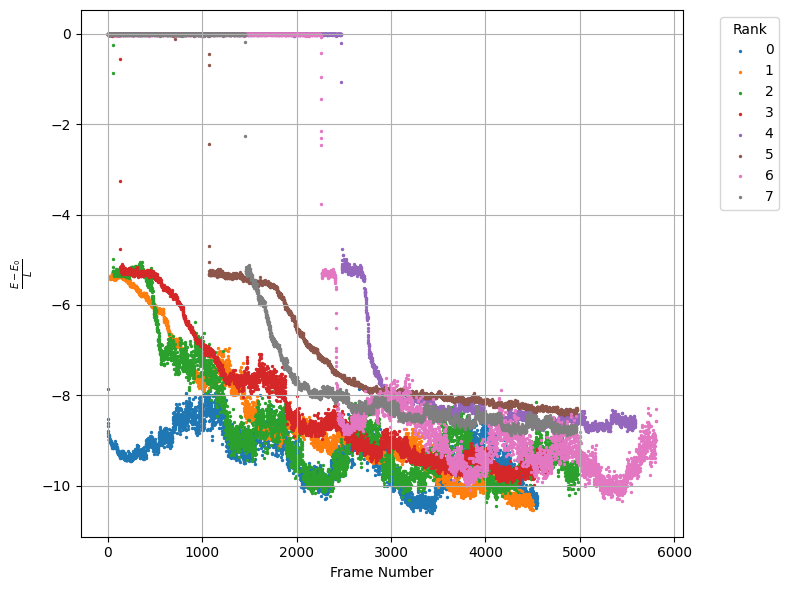

In [7]:
plt.figure(figsize=(8, 6))
for rank, group in df_curves.groupby('rankNumber'):
    plt.scatter(group['frameNumber'], group['energy'], s=2, label=f"{rank}")

plt.xlabel("Frame Number")
plt.ylabel(r"$\frac{E - E_{0}}{L}$")
plt.legend(title="Rank", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()

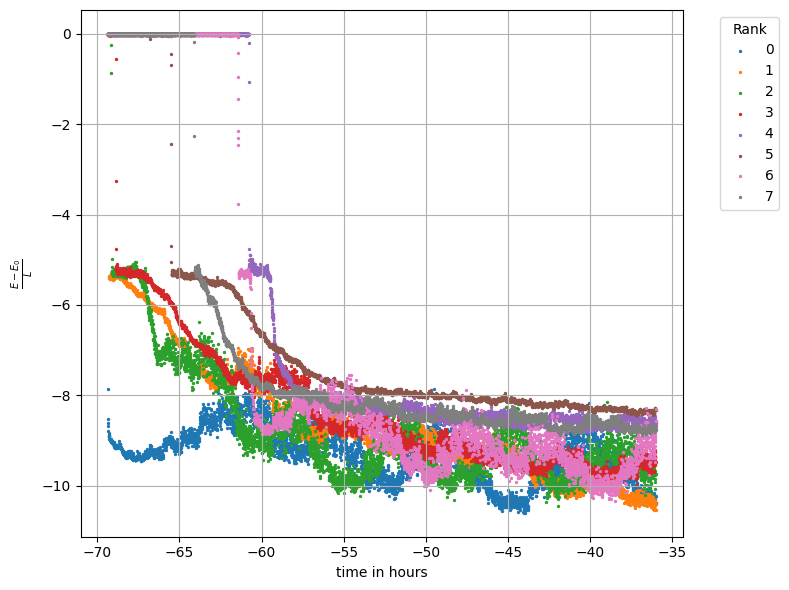

In [8]:
plt.figure(figsize=(8, 6))
for rank, group in df_curves.groupby('rankNumber'):
    plt.scatter((np.array(group['time_in_sequence'])/(60*60)).tolist(), group['energy'], s=2, label=f"{rank}")

plt.xlabel("time in hours")
plt.ylabel(r"$\frac{E - E_{0}}{L}$")
plt.legend(title="Rank", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()

In [9]:
orga_info = []

for rank, group in df_curves.groupby('rankNumber'):
    # Find the row where energy is at its minimum
    min_energy_idx = group['energy'].idxmin()
    min_row = group.loc[min_energy_idx]
    
    # Calculate ranges for this specific rank
    e_range = group['energy'].max() - group['energy'].min()
    t_range = group['temp'].max() - group['temp'].min()
    
    # Print out matching your exact style
    print(f"Rank = {rank}  MIN E = {min_row['energy']:.10f} curve id = {group['energy'].idxmin()}, frnber= {int(min_row['frameNumber'])} T= {min_row['temp']:.6f} temps in ["+str(group['temp'].min())+","+str(group['temp'].max())+"] and energy in ["+str(group['energy'].min())+","+str(group['energy'].max())+"]")
    
    # Append to your tracking list
    orga_info.append({
        "rank": rank,
        "curve_id": min_row['id'],  # Pulls the exact curve ID for the minimum row
        "min_energy": min_row['energy'],
        "frame_number": int(min_row['frameNumber']),
        "temp_at_min": min_row['temp']
    })

Rank = 0  MIN E = -10.5988600000 curve id = 3432, frnber= 3432 T= 0.186380 temps in [0.05,0.5] and energy in [-10.59886,-7.65683]
Rank = 1  MIN E = -10.5377100000 curve id = 9052, frnber= 4501 T= 0.134135 temps in [0.05,0.258974] and energy in [-10.53771,-0.00533]
Rank = 2  MIN E = -10.4467500000 curve id = 13171, frnber= 4118 T= 0.258974 temps in [0.096535,0.5] and energy in [-10.44675,-0.00624]
Rank = 3  MIN E = -9.9821700000 curve id = 18547, frnber= 4514 T= 0.186380 temps in [0.05,0.258974] and energy in [-9.98217,-0.0034]
Rank = 4  MIN E = -8.8148900000 curve id = 23788, frnber= 5086 T= 0.069475 temps in [0.069475,0.5] and energy in [-8.81489,-0.00326]
Rank = 5  MIN E = -8.4442700000 curve id = 29127, frnber= 4835 T= 0.050000 temps in [0.05,0.258974] and energy in [-8.44427,-0.00335]
Rank = 6  MIN E = -10.3387200000 curve id = 34711, frnber= 5448 T= 0.258974 temps in [0.096535,0.5] and energy in [-10.33872,-0.00315]
Rank = 7  MIN E = -8.8700300000 curve id = 39340, frnber= 4270 T=

In [10]:

#add information of lowest energy etc. to the _experiments table
min_record = min(orga_info, key=lambda x: x['min_energy'])

min_energy_val = min_record['min_energy'] #energy is normalised E-E_0/L
best_curve_id = min_record['curve_id']
min_energy_computed = " (E - E0)/L at "+str(min_record['curve_id'])


with sqlite3.connect(DB_FILE) as conn:
    # This isolation level forces SQLite to clear any pending reading states
    conn.isolation_level = None  
    cursor = conn.cursor()
    
    # Run a quick check right inside this clean session
    cursor.execute("SELECT id FROM _experiments WHERE id = ?", [exp_id])
    exists = cursor.fetchone()
    print(f"Clean session check -> Does ID {exp_id} exist?: {'Yes' if exists else 'No'}")
    
    if exists:
        query_update = """
        UPDATE _experiments 
        SET minEnergy_normalised = ?, min_energy_computed = ?
        WHERE id = ?
        """
        cursor.execute(query_update, [float(min_energy_val), str(min_energy_computed), exp_id])
        
        # Manually commit since we turned off auto-isolation
        conn.commit()
        print(f"Rows successfully updated: {cursor.rowcount}")
    else:
        print("Skipping update because the ID still wasn't found in this session.")

Clean session check -> Does ID 1 exist?: Yes
Rows successfully updated: 1


In [11]:
import gc

print("Cleaning up database connections...")

# 1. Look through all active variables in the notebook's memory
for var_name in list(globals().keys()):
    var = globals()[var_name]
    
    # If the variable is an active SQLite connection, shut it down
    if isinstance(var, sqlite3.Connection):
        try:
            var.close()
            print(f"  -> Closed lingering connection variable: '{var_name}'")
        except sqlite3.ProgrammingError:
            # Connection was already closed
            pass

# 2. Force Python to clear cached memory objects holding file handles
gc.collect()

print("\nDatabase is completely unlocked and ready for external use!")

Cleaning up database connections...
  -> Closed lingering connection variable: 'conn'

Database is completely unlocked and ready for external use!
